# VisualAstro Styles Guide

visualastro comes with many matplotlib styles to use when making figures! Here is a quick tutorial on how to use them!

visualastro automatically registers all the packaged styles with matplotlib, so you do not need to import them! You are also
free to add as many styles as you want, by simply adding a `mynewstyle.mplstyle` style sheet in the `visualastro/src/visualastro/stylelib/` folder! Your style will then be available under the name `mynewstyle`. If you choose to modify visualastro, make sure you are doing so on a fork so that you don't loose your changes if you update the package!


In [1]:
import astropy.units as u
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import visualastro as va

# set some defaults
va.config.figsize = (5, 5)
va.config.figsize3D = (4, 4)

To enable a style, use the `plt.style.use` method. This will set all matplotlib global style variables to whatever style you choose.
visualastro comes with many custom styles, which are listed in `va.config.style_available`. You can also use any style from `scienceplots` https://github.com/garrettj403/SciencePlots, or any of the available matplotlib styles https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html!

## A Description of the Styles

### Font Styles
These change the font of your figure
* hershey : AVHershey Truetype font
* courier : Courier Monospace font
* courier-new : Courier New Monospace font
* andale-mono : Andale Monospace font
* dejavu-mono : DejaVu Monospace font
* mono : default matplotlib Monospace font

### Axes Styles
These change the axes style of your figure
* full : Apply major and minor ticks facing in on all axes splines
* minimal : Apply major ticks facing out on only the left and bottom axes splines

In [2]:
# all available visualastro styles
va.config.style_available

['andale-mono',
 'astro',
 'courier',
 'dejavu-mono',
 'full',
 'minimal',
 'thorlabs',
 'mono',
 'courier-new',
 'hershey',
 'cmu',
 'latex',
 'cm10',
 'smplot',
 'smplot-og']

In [3]:
# we can update all our plots to use the Courier-New font
plt.style.use('hershey')

In [4]:
# create some data
x = np.linspace(0, 5, 500)
y = np.linspace(0, 5, 500)
X, Y = np.meshgrid(x, y)

with np.errstate(invalid='ignore', divide='ignore'):
    Z = 1/np.sin(np.tan(10/X**Y)) - 1/np.sin(np.tan(10/Y**X))

# lets define some more data
r_p = 1.0
theta = np.linspace(0, 2 * np.pi, 500)
e_vals = [0.0, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.95, 1.4, 1.5, 2]
a_vals = [r_p / (1 - e) for e in e_vals]
r_vals = [a * (1 - e**2) / (1 + e * np.cos(theta)) for (a, e) in zip(a_vals, e_vals)]
x_vals = [r * np.cos(theta) for r in r_vals]
y_vals = [r * np.sin(theta) for r in r_vals]

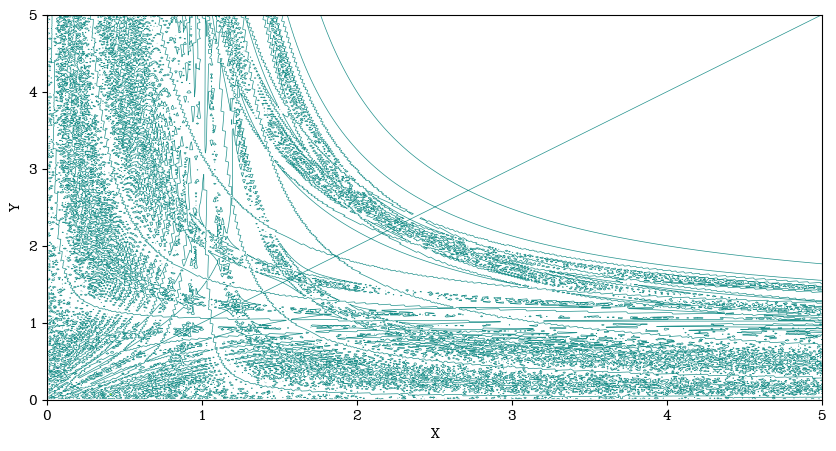

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.contour(X, Y, Z, linewidths=0.5, cmap='viridis')

ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()

As you can see, we are now using the AVHershey fonts used in the supermongo plotting package!

We can also apply style(s) temporarily using `plt.style.context` instead! Everything inside of the `with` block will have the style applied.
It is also possible to chain styles together! The rightmost style takes precedence in the event of conflicting parameters.

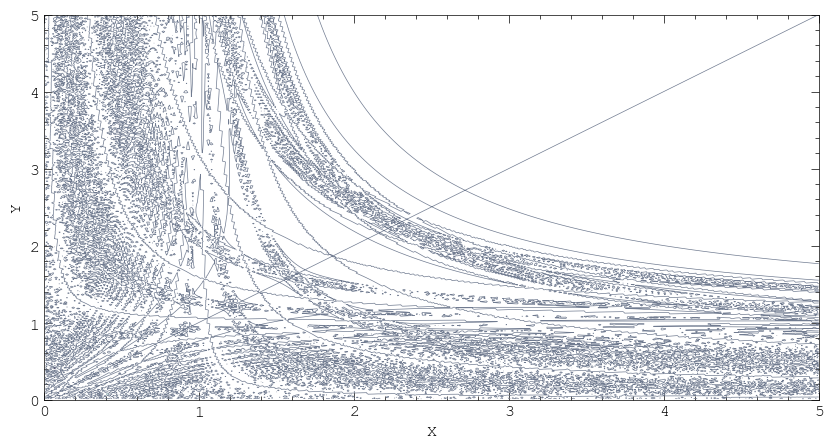

In [6]:
with plt.style.context(['full', 'courier-new']):
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.contour(X, Y, Z, linewidths=0.5, cmap='bone')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    plt.show()

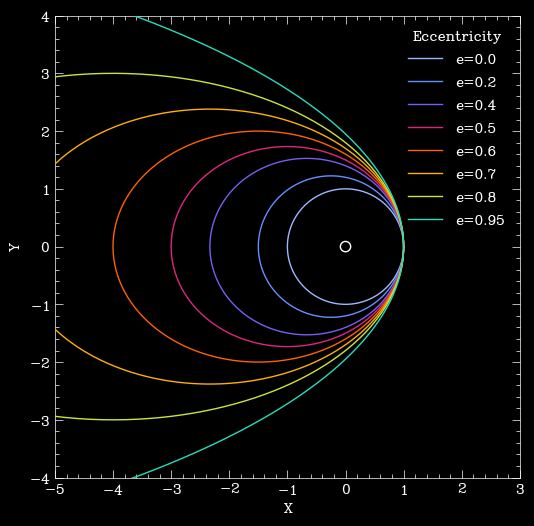

In [7]:
colors = va.get_colors('astro_seq')
labels = [f'e={e}' for e in e_vals]
with plt.style.context(['full', 'dark_background']):
    fig, ax = plt.subplots(figsize=(6,6))

    va.plot(
        x_vals[:8], y_vals[:8], ax=ax, 
        label=labels, color=colors, lw=1, 
        xlim=(-5, 3), ylim=(-4, 4),
        xlabel='X', ylabel='Y'
    )

    ax.scatter(0, 0, color='w', fc='none', s=55)

    plt.legend(loc='upper right', title='Eccentricity')

    plt.show()

You can also change the style in any of the `va.ax` plots using the `style` keyword argument.

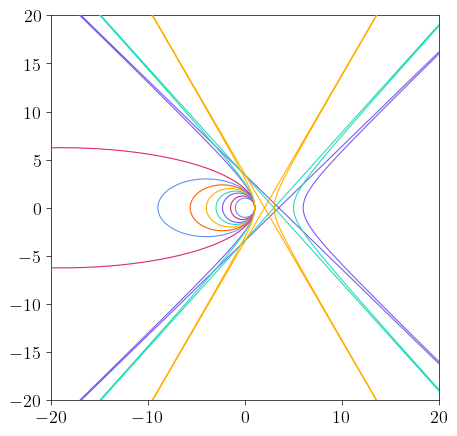

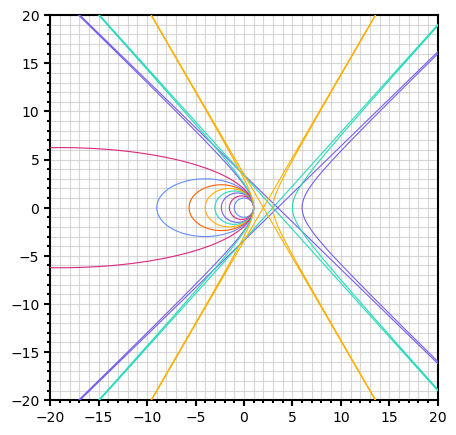

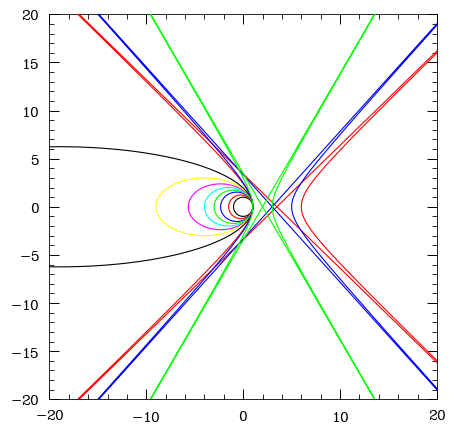

In [8]:
# caution, this requires a LaTeX installation!
va.ax.plot(x_vals, y_vals, style=['latex', 'minimal'], scale=20)
va.ax.plot(x_vals, y_vals, style='thorlabs', scale=20)
va.ax.plot(x_vals, y_vals, style='smplot-og', scale=20, color=None)

Here are sample plot made with the available visualastro plot styles. 
Each style sets the axes, fonts and font sizes, but leaves the color up to the user.



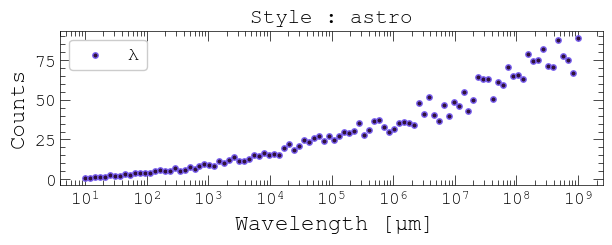

/var/folders/h7/cx5lwbdn34b_yknl3ypdx1780000gn/T/ipykernel_18324/405446030.py:2: UserWarning: 
  va.help.style()


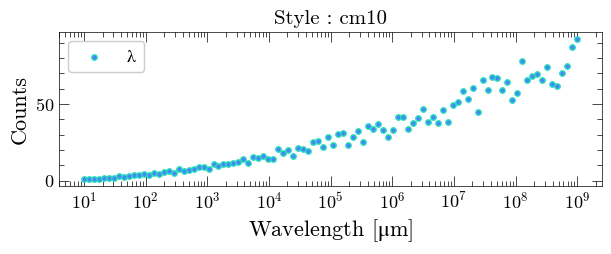

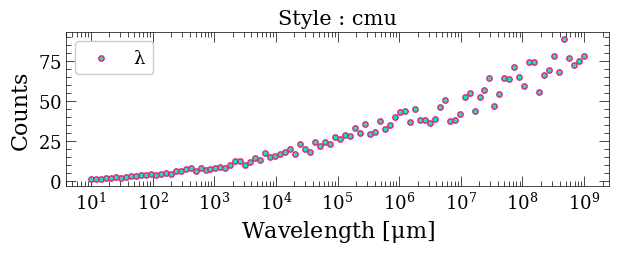

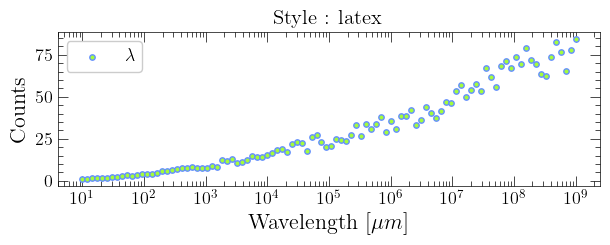

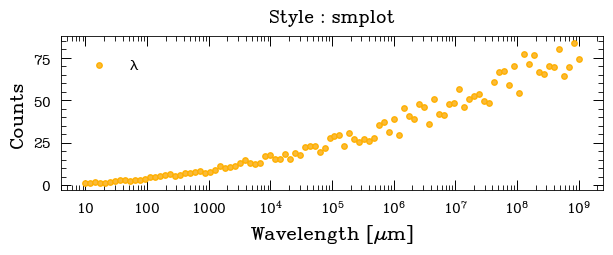

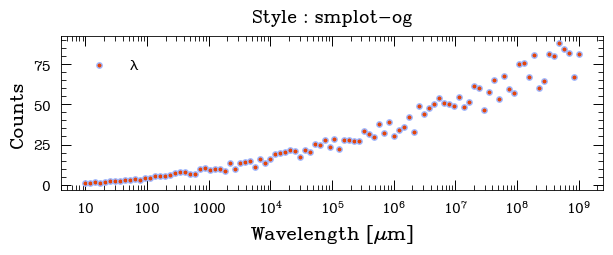

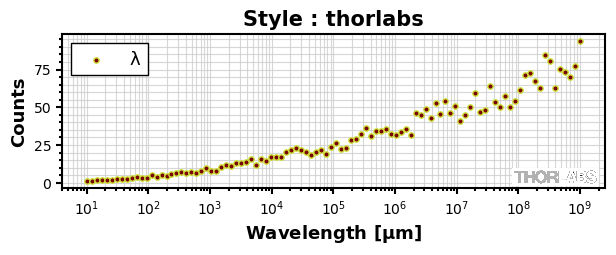

In [9]:
# Here are more styles
va.help.style()

### 3D Plot Styles

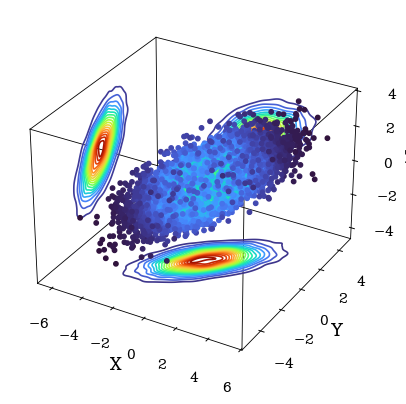

In [10]:
blob = va.blob(10000, as_array=True)
dens = va.number_density(blob, 2000)
va.config.cmap = 'turbo'
va.ax.scatter3D(blob, axis_style='cube', c=dens, plot_contours='all')

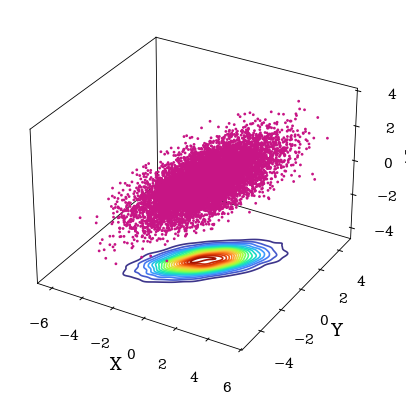

In [11]:
va.ax.scatter3D(blob, axis_style='panel', color='mediumvioletred', s=1, plot_contours='z')

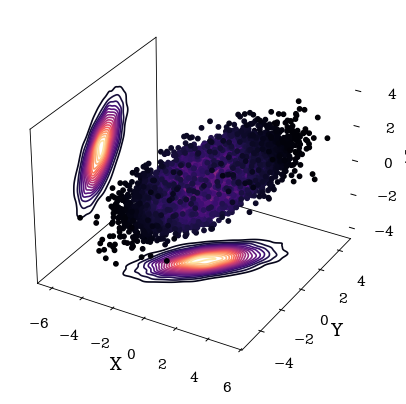

In [12]:
va.ax.scatter3D(blob, axis_style='y_panel', plot_contours=['x', 'z'], cmap='magma', c=dens)

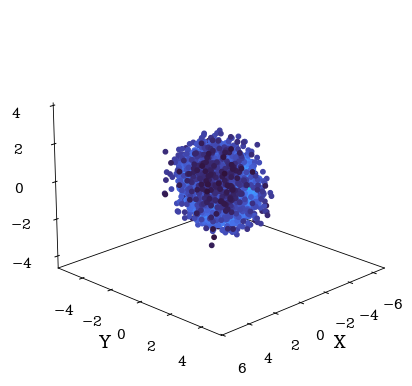

In [13]:
va.ax.scatter3D(blob, axis_style='floor', elev=20, azim=45, c=dens)

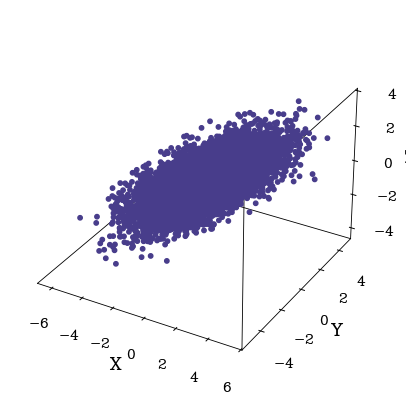

In [14]:
# some of the 3D styles can be reveresed 
va.ax.scatter3D(blob, axis_style='y_panel_r', color='darkslateblue')

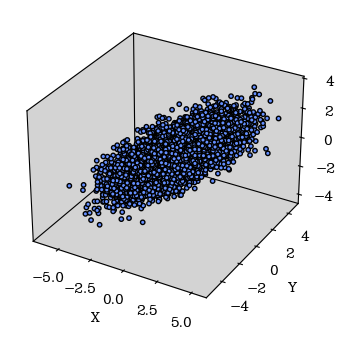

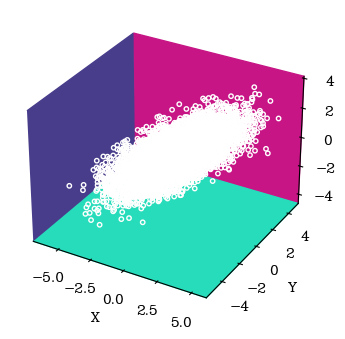

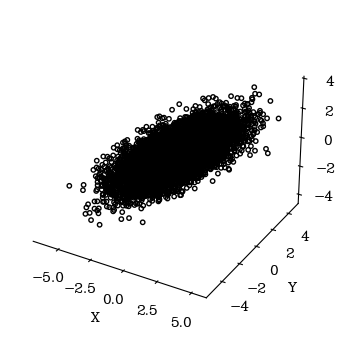

In [15]:
fig, ax = va.ax3d()
va.scatter3D(blob, ax=ax, ec='k')

va.ax3d_pane_color('lightgrey', ax=ax)
va.ax3d_axis_style(ax, 'panel')

plt.show()

fig, ax = va.ax3d()
va.scatter3D(blob, ax=ax, color='w', fc='none')

va.ax3d_pane_color(['darkslateblue', 'mediumvioletred', 'jade'], ax=ax)

plt.show()

fig, ax = va.ax3d()
va.scatter3D(blob, ax=ax, color='k', fc='none')

va.ax3d_axis_style(ax, None)

plt.show()

In [16]:
help(va.ax3d_axis_style)

Help on function ax3d_axis_style in module visualastro.plotting.core.axes:

ax3d_axis_style(ax: mpl_toolkits.mplot3d.axes3d.Axes3D, style: str | None = 'cube') -> None
    Set the spine style of a 3D matplotlib axes by drawing explicit edge lines.
    
    Overrides matplotlib axes rendering while keeping the ticks and tick labels.
    For this reason these styles are experimental and may break in interactive mode.
    
    The styles are defined with respect to the default matplotlib viewing angles of
    `elev=30`, `azim=-60`, and `roll=0`.
    
    Parameters
    ----------
    ax : Axes3D
        Target 3D axes object.
    style : str | None, optional, default='cube'
        Spine layout to apply.
    
        * `'triad'`        : 3 edges from the front-right-bottom corner (matplotlib default-like).
        * `'floor'`        : 4 bottom edges of the bounding box.
        * `'ceiling'`      : 4 top edges of the bounding box.
        * `'cube'`         : all 12 edges of the bounding 